Objective

The purpose of this experiment is to investigate whether enabling data augmentation improves the generalisation and robustness of the YOLOv8n model for underwater waste detection.


Code Description

This experiment uses the YOLOv8n object detection model with data augmentation enabled. The augmentation settings include colour adjustment, rotation, scaling, translation, flipping, mosaic, and mixup. These techniques increase image variation during training and help the model generalise better to unseen underwater waste images.


Setup and Dataset Path Code

Add this before the training code. It installs YOLOv8, mounts Google Drive, and creates a fixed dataset YAML that points to the correct dataset folders.


In [1]:
!nvidia-smi

Thu May  7 03:45:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.5 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
from google.colab import drive
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!find "/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19" -type d

/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/cfgs_and_weights
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/cfgs_and_weights/yolo
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/cfgs_and_weights/yolo/cfg
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/cfgs_and_weights/yolo/weights
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/test
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/test/images
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/test/labels
/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o

In [10]:
fixed_yaml = """
path: /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset
train: train/images
val: val/images
test: test/images

names:
  0: plastic
  1: bio
  2: rov
"""

with open("/content/drive/MyDrive/fixed_data.yaml", "w") as f:
    f.write(fixed_yaml)

DATASET_PATH = "/content/drive/MyDrive/fixed_data.yaml"

print("YAML exists:", os.path.exists(DATASET_PATH))

YAML exists: True


Training Code

This is the final Member 4 training cell. Use 30 epochs if you want a faster run, or change it to 50 if your group requires the longer experiment.


In [12]:
model_aug = YOLO("yolov8n.pt")

results_aug = model_aug.train(
    data=DATASET_PATH,
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    name="member4_yolov8n_augmentation",

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1
)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/fixed_data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=member4_yolov8n_augmentation-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

Metrics Output

The trained model was evaluated using precision, recall, mAP50, and mAP50-95. These metrics measure detection correctness, object coverage, and overall object detection performance.


In [13]:
metrics_aug = model_aug.val()
print(metrics_aug)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.3 ms, read: 11.2±5.5 MB/s, size: 20.3 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/labels.cache... 820 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 820/820 229.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 3.8it/s 13.8s
                   all        820       1064       0.47      0.458      0.467      0.288
               plastic        819        853      0.791      0.784      0.858      0.564
                   bio         54         70      0.116     0.0857      0.048     0.0222
                   rov        141        141      0.503      0.504      0.494      0.276
Speed: 1.2ms preprocess, 3.4ms inference, 0.0ms loss, 2.0ms postp

Precision: 0.47

Recall: 0.46

mAP50: 0.47

mAP50-95: 0.29


In [15]:
!cp -r /content/runs /content/drive/MyDrive/member4_backup

In [17]:
!find /content/runs -name "best.pt"

/content/runs/detect/member4_yolov8n_augmentation-2/weights/best.pt


In [19]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/member4_yolov8n_augmentation-2/weights/best.pt")

Prediction Outputs

The following prediction outputs demonstrate the model’s ability to detect and classify underwater waste objects after augmentation was applied during training.


In [20]:
results = best_model.predict(
    source="/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images",
    conf=0.25,
    save=True
)


image 1/820 /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images/obj0029_frame0000025.jpg: 480x640 1 plastic, 67.2ms
image 2/820 /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images/obj0029_frame0000026.jpg: 480x640 1 plastic, 8.8ms
image 3/820 /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images/obj0029_frame0000028.jpg: 480x640 1 plastic, 8.5ms
image 4/820 /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images/obj0029_frame0000029.jpg: 480x640 1 plastic, 9.0ms
image 5/820 /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images/obj0029_frame0000030.jpg: 480x640 1 plastic, 11.0ms
image 6/820 /content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images/obj0029_frame0000032.jpg: 480x640 1 plas

Show only three prediction images:

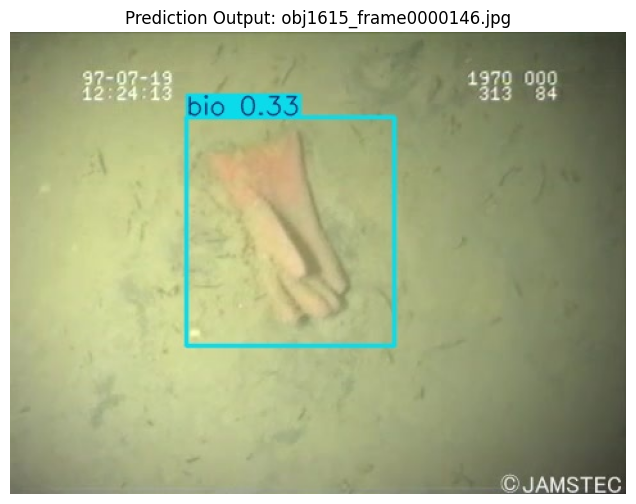

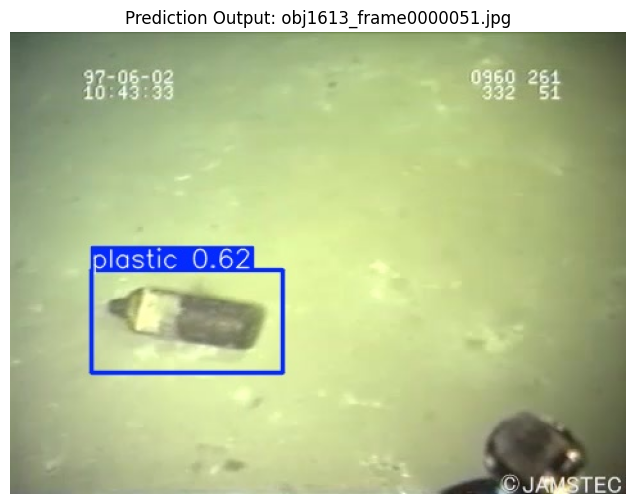

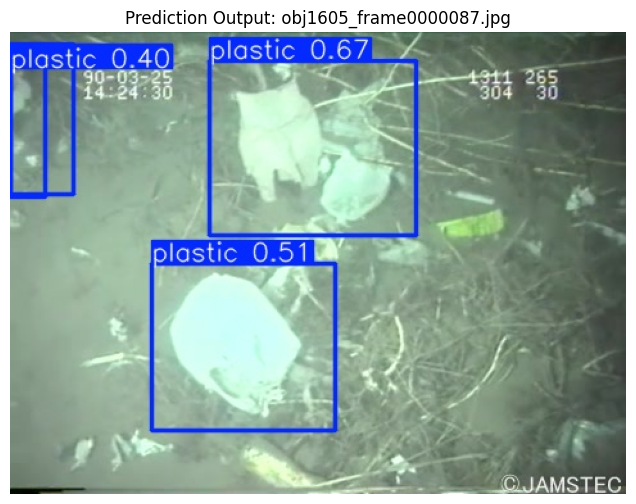

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import os

pred_folder = "/content/runs/detect/predict"

images = os.listdir(pred_folder)[:3]

for img_name in images:
    img = Image.open(os.path.join(pred_folder, img_name))

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title("Prediction Output: " + img_name)
    plt.axis("off")
    plt.show()

Original vs Prediction Comparison

The following comparisons illustrate the differences between the original underwater images and the model-generated predictions after augmentation training.


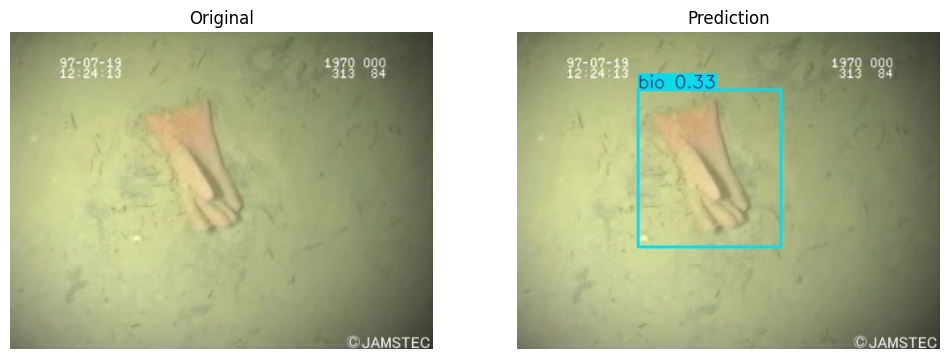

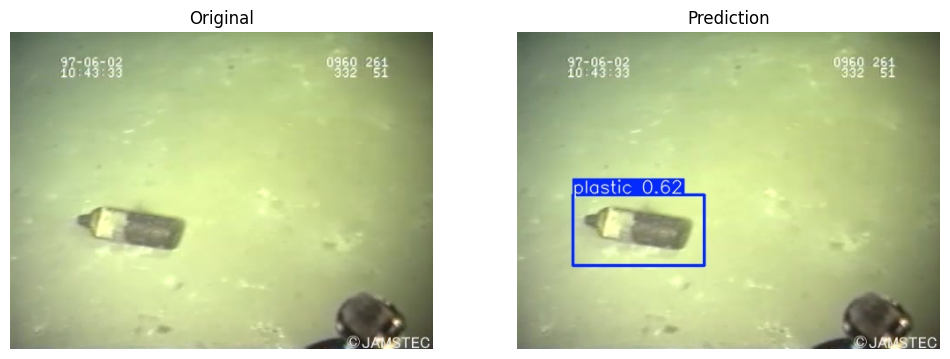

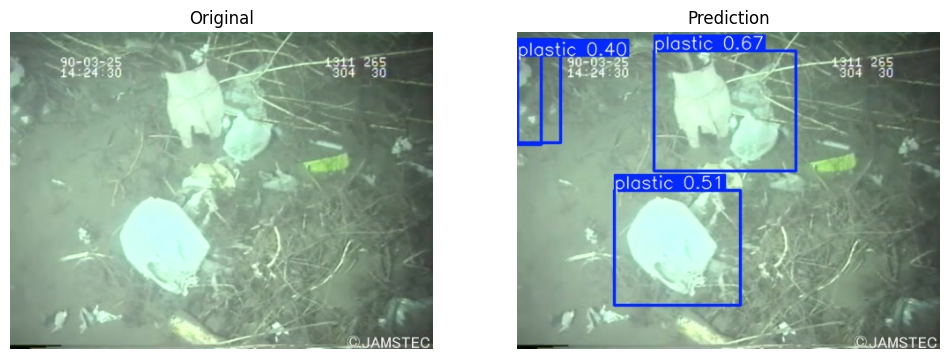

In [22]:
orig_folder = "/content/drive/.shortcut-targets-by-id/1BzlXCMaN335NjAzPSN4OKwengg915o0d/trash_ICRA19/dataset/val/images"
pred_folder = "/content/runs/detect/predict"

images = os.listdir(pred_folder)[:3]

for img_name in images:
    fig, axs = plt.subplots(1,2, figsize=(12,5))

    axs[0].imshow(Image.open(os.path.join(orig_folder, img_name)))
    axs[0].set_title("Original")

    axs[1].imshow(Image.open(os.path.join(pred_folder, img_name)))
    axs[1].set_title("Prediction")

    for ax in axs:
        ax.axis("off")

    plt.show()

In [23]:
!ls /content/runs/detect

member4_yolov8n_augmentation  member4_yolov8n_augmentation-2  predict  val


### Confusion Matrix

The confusion matrix provides a visual representation of the model’s classification performance across different underwater waste categories.

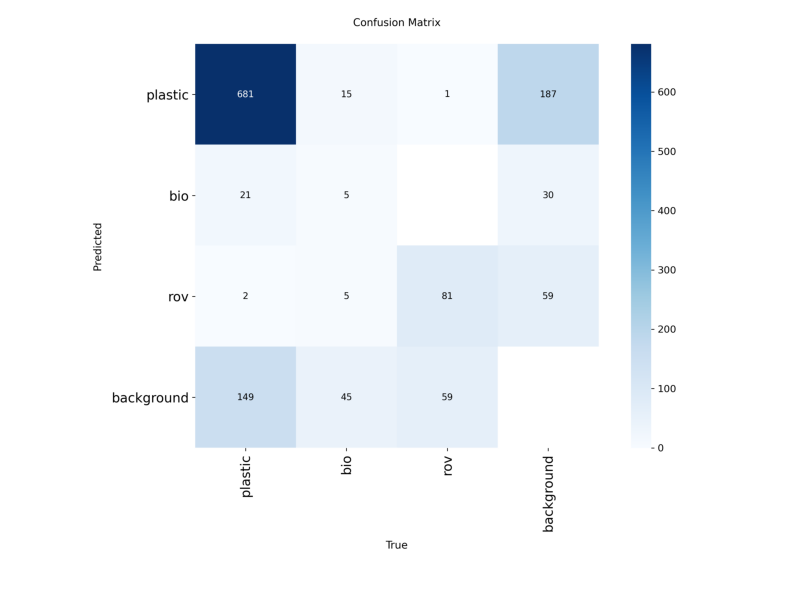

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/member4_yolov8n_augmentation-2/confusion_matrix.png")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.show()

Prediction Analysis

The prediction outputs indicate that enabling augmentation improved the model’s ability to generalise across different underwater conditions. The model demonstrated more stable object detection performance in images with cluttered backgrounds and varying visibility conditions.
The augmented model performed best on the plastic class, while the bio class had weaker detection performance. This may be due to fewer bio samples or visual similarity between bio waste and the underwater background.

Failure Analysis

Although augmentation improved the robustness of the model, several limitations remained. The model may still struggle with small objects, overlapping objects, low visibility, inconsistent lighting, and background noise.
The validation results show that the bio class had lower performance compared with plastic and rov. This suggests that class imbalance or limited examples may affect the model’s ability to detect this class accurately.

Conclusion

This experiment demonstrated that data augmentation can improve the robustness of YOLOv8n for underwater waste detection. The model achieved usable detection performance after applying augmentation techniques such as flipping, scaling, colour adjustment, mosaic, and mixup.
Overall, augmentation helped the model generalise better to different underwater conditions, although further improvement may be possible using more balanced data, longer training, or a larger YOLOv8 model.
